<a href="https://colab.research.google.com/github/osmankantarcioglu/osmankantarcioglu/blob/main/CS412_HW2_OsmanKantarcioglu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning - Homework 2: Part 1

## 1. Dataset Generation

The dataset that will be used throughout this part is already created and split for you. Do not change any part of the code below.

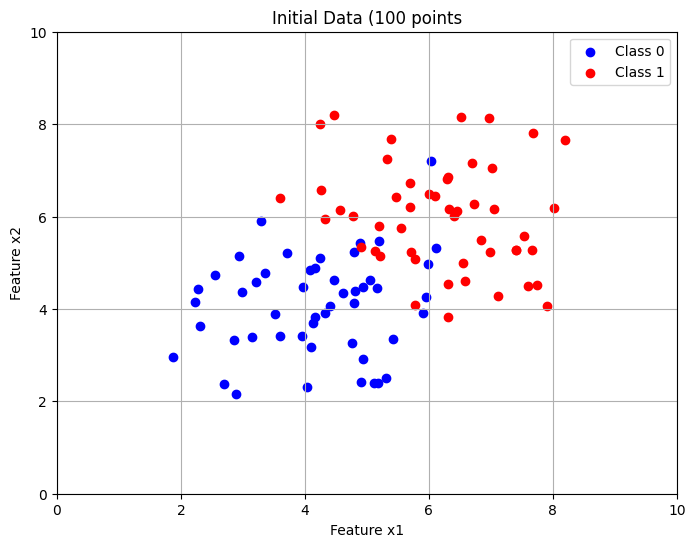

In [3]:
############# DO NOT CHANGE THIS PART #############

import numpy as np
import matplotlib.pyplot as plt

def generate_dataset(n_points_per_class, seed):
    """
    Generates a 2-class dataset with 2 features.
    The classes are Gaussian clusters that have some overlap.

    Args:
    n_points_per_class (int): Number of points for class 0 and class 1
    seed (int): Random seed for reproducibility

    Returns:
    X (ndarray): (n_points*2, 2) array of features
    y (ndarray): (n_points*2,) array of labels (0 or 1)
    """
    np.random.seed(seed)

    # Class 0 properties: Centered at (4, 4)
    mean_0 = [4, 4]
    # Covariance matrix: [[var_x, cov_xy], [cov_xy, var_y]]
    # This creates an elliptical cluster
    cov_0 = [[1.5, 0.5], [0.5, 1.5]]

    # Class 1 properties: Centered at (6, 6)
    mean_1 = [6, 6]
    # This cluster slants the other way
    cov_1 = [[1.5, -0.5], [-0.5, 1.5]]

    # Generate the points
    class_0_x = np.random.multivariate_normal(mean_0, cov_0, n_points_per_class)
    class_1_x = np.random.multivariate_normal(mean_1, cov_1, n_points_per_class)

    # Combine into X and y
    X = np.concatenate((class_0_x, class_1_x))
    y = np.array([0]*n_points_per_class + [1]*n_points_per_class)

    return X, y

# Dataset generation
seed = 42
n_points_total = 100
n_per_class = n_points_total // 2

X, y = generate_dataset(n_points_per_class=n_per_class, seed=seed)

# Displat the dataset
title = f"Initial Data ({n_points_total} points"
plt.figure(figsize=(8, 6))

# Plot the data points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')

plt.xlim(0, 10) # Adjusted for new data
plt.ylim(0, 10) # Adjusted for new data
plt.xlabel('Feature x1')
plt.ylabel('Feature x2')
plt.legend()
plt.title(title)
plt.grid(True)
plt.show()

############# DO NOT CHANGE THIS PART #############

# Machine Learning - Homework 2: Part 2

## 1. Dataset Generation

The dataset that will be used throughout this part is already created and split for you. Do not change any part of the code below.

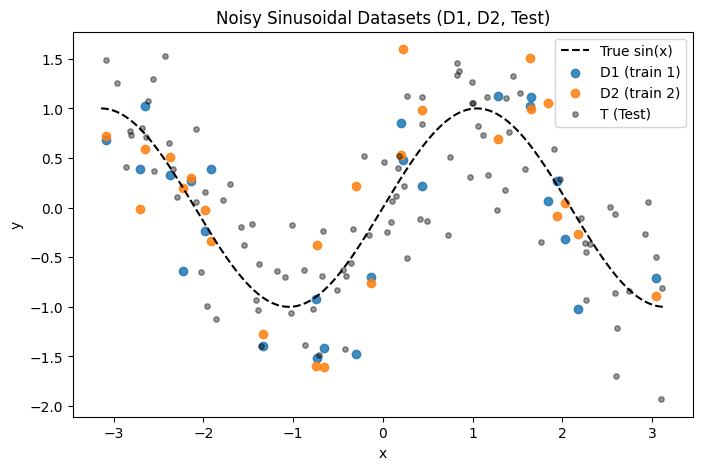

In [4]:
############# DO NOT CHANGE THIS PART #############

import numpy as np
import matplotlib.pyplot as plt

# Initial configurations
N_train = 25                 # points in D1 and D2
N_test = 100                 # points in test set
sigma = 0.5                 # standard deviation of noise
period = 2 * np.pi           # one period of sine wave
freq = 1.5                   # frequency of the sinusoidal
start_point = -period/2
end_point = start_point + period

# Dataset generation function
def make_dataset(n_points, sigma, seed_x, seed_noise):
    rng_x = np.random.default_rng(seed_x)
    rng_n = np.random.default_rng(seed_noise)

    X = np.sort(rng_x.uniform(start_point, end_point, size=n_points))
    noise = rng_n.normal(0.0, sigma, size=n_points)
    y = np.sin(freq*X) + noise

    return X.reshape(-1, 1), y

# Create datasets
X1, y1 = make_dataset(N_train, sigma, seed_x=412955, seed_noise=412067)  # D1
X2, y2 = make_dataset(N_train, sigma, seed_x=412955, seed_noise=412085)  # D2
Xt, yt = make_dataset(N_test,  sigma, seed_x=412738, seed_noise=412222)  # Test set

# Visualize the generated data
plt.figure(figsize=(8,5))
x_true = np.linspace(start_point, end_point, 400)
y_true = np.sin(freq*x_true)

plt.plot(x_true, y_true, 'k--', label='True sin(x)')
plt.scatter(X1, y1, color='tab:blue', label='D1 (train 1)', alpha=0.85)
plt.scatter(X2, y2, color='tab:orange', label='D2 (train 2)', alpha=0.85)
plt.scatter(Xt, yt, color='black', label='T (Test)', alpha=0.4, s=15)
plt.legend()
plt.title("Noisy Sinusoidal Datasets (D1, D2, Test)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


############# DO NOT CHANGE THIS PART #############

# **PART 1**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# CS412 HW2 — Part 1: Logistic Regression with Gradient Descent
# --------------------------------------------------------------
# This script implements logistic regression using gradient descent from scratch.
# It performs two experiments:
#   (1) Fixed number of iterations (10)
#   (2) Stop when |ΔJ| < 1e-5
# It also plots the decision boundaries and reports all numerical results
# with exactly 4 digits after the decimal point (no rounding).

In [7]:
# ==============================
# Logistic Regression utilities
# ==============================
def sigmoid(z):
    """Sigmoid activation function."""
    return 1.0 / (1.0 + np.exp(-z))

def bce_cost(y_true, y_pred):
    """Binary cross-entropy cost function."""
    eps = 1e-12  # prevent log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def extend_with_bias(X):
    """Adds a column of 1s for the bias term w0."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

def predict_proba(W, X_ext):
    """Computes predicted probabilities."""
    return sigmoid(X_ext @ W)

def predict_label(W, X_ext, threshold=0.5):
    """Converts probabilities to class predictions (0/1)."""
    return (predict_proba(W, X_ext) >= threshold).astype(int)

def classification_error_rate(y_true, y_pred_labels):
    """Computes classification error rate."""
    return np.mean(y_true != y_pred_labels)

# Truncate to 4 decimal places (no rounding)
def truncate_4(x):
    factor = 10000.0
    return np.trunc(np.asarray(x, dtype=float) * factor) / factor

def format_array_trunc(a):
    """Formats numpy array with truncated 4-decimal values."""
    a = truncate_4(a)
    return np.array2string(a, formatter={'float_kind': lambda v: f"{v:.4f}"})

In [8]:
# ==============================
# Gradient Descent implementation
# ==============================
def logistic_gd(X, y, lr=0.1, max_iter=10000, tol=None, W_init=None):
    """
    Performs gradient descent for logistic regression.

    Args:
        X: (N, 2) feature matrix
        y: (N,) labels (0 or 1)
        lr: learning rate
        max_iter: maximum number of iterations
        tol: tolerance for |ΔJ| stopping condition
        W_init: initial weights [w0, w1, w2]
    """
    X_ext = extend_with_bias(X)  # add bias column
    N = X_ext.shape[0]
    W = np.zeros(3) if W_init is None else W_init.astype(float).copy()
    costs = []

    for t in range(max_iter):
        y_hat = predict_proba(W, X_ext)
        J = bce_cost(y, y_hat)
        costs.append(J)

        # Gradient: (1/N) * X_ext^T * (y_hat - y)
        grad = (X_ext.T @ (y_hat - y)) / N

        # Gradient descent update
        W = W - lr * grad

        # Check stopping condition
        if tol is not None and t > 0:
            if abs(costs[-2] - costs[-1]) < tol:
                break

    return W, np.array(costs), t + 1


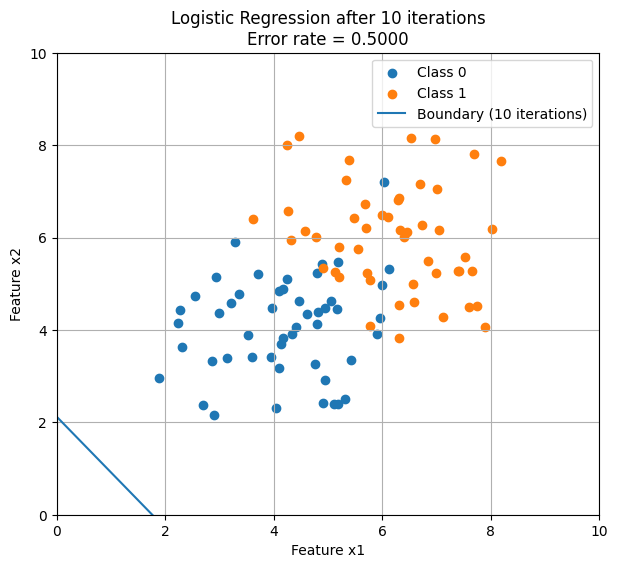

In [9]:
# ==============================
# Experiment 1: Fixed 10 iterations
# ==============================
eta = 0.1
W0 = np.zeros(3)
W_10, costs_10, iters_10 = logistic_gd(X, y, lr=eta, max_iter=10, tol=None, W_init=W0)

X_ext = extend_with_bias(X)
err_10 = classification_error_rate(y, predict_label(W_10, X_ext))

# Plot dataset and decision boundary
plt.figure(figsize=(7, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1')
plt.xlim(0, 10); plt.ylim(0, 10)
plt.xlabel('Feature x1'); plt.ylabel('Feature x2')

# Decision boundary: w1*x1 + w2*x2 + w0 = 0 → x2 = -(w1*x1 + w0)/w2
x_vals = np.linspace(0, 10, 200)
if abs(W_10[2]) > 1e-12:
    y_vals = -(W_10[1]*x_vals + W_10[0]) / W_10[2]
    plt.plot(x_vals, y_vals, label='Boundary (10 iterations)')

plt.title(f'Logistic Regression after 10 iterations\nError rate = {truncate_4(err_10):.4f}')
plt.legend(); plt.grid(True)
plt.show()

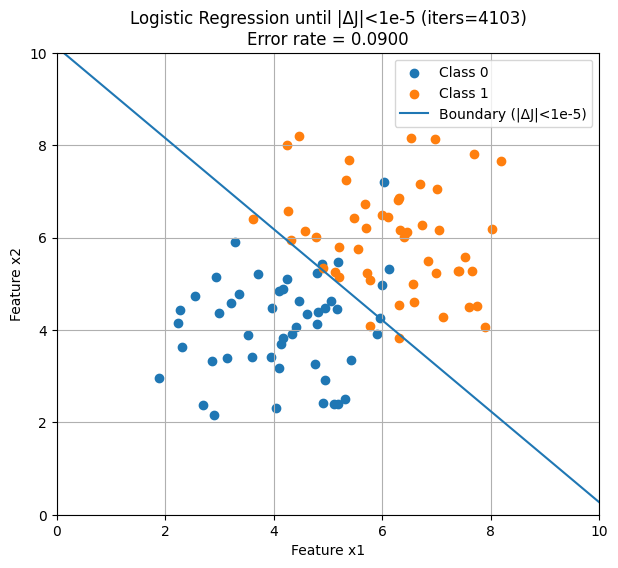

In [10]:
# ==============================
# Experiment 2: Stop when |ΔJ| < 1e-5
# ==============================
W_tol, costs_tol, iters_tol = logistic_gd(X, y, lr=eta, max_iter=200000, tol=1e-5, W_init=W0)
err_tol = classification_error_rate(y, predict_label(W_tol, X_ext))

# Plot dataset and final decision boundary
plt.figure(figsize=(7, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1')
plt.xlim(0, 10); plt.ylim(0, 10)
plt.xlabel('Feature x1'); plt.ylabel('Feature x2')

if abs(W_tol[2]) > 1e-12:
    y_vals = -(W_tol[1]*x_vals + W_tol[0]) / W_tol[2]
    plt.plot(x_vals, y_vals, label='Boundary (|ΔJ|<1e-5)')

plt.title(f'Logistic Regression until |ΔJ|<1e-5 (iters={iters_tol})\nError rate = {truncate_4(err_tol):.4f}')
plt.legend(); plt.grid(True)
plt.show()


In [11]:
# ==============================
# Print required numerical outputs
# ==============================
print("=== Experiment 1: Fixed 10 iterations ===")
print("Final parameters [w0, w1, w2]_t=10:", format_array_trunc(W_10))
print("Final cost:", f"{truncate_4(costs_10[-1]):.4f}")
print("Error rate:", f"{truncate_4(err_10):.4f}")
print()

print("=== Experiment 2: Until |ΔJ| < 1e-5 ===")
print("Iterations run:", iters_tol)
print("Final parameters [w0, w1, w2]:", format_array_trunc(W_tol))
print("Final cost:", f"{truncate_4(costs_tol[-1]):.4f}")
print("Error rate:", f"{truncate_4(err_tol):.4f}")

=== Experiment 1: Fixed 10 iterations ===
Final parameters [w0, w1, w2]_t=10: [-0.0822 0.0468 0.0388]
Final cost: 0.6690
Error rate: 0.5000

=== Experiment 2: Until |ΔJ| < 1e-5 ===
Iterations run: 4103
Final parameters [w0, w1, w2]: [-10.5786 1.0299 1.0453]
Final cost: 0.2629
Error rate: 0.0900


# **PART 2**

In [12]:
# CS412 HW2 — Part 2: Polynomial Regression (+ Regularization)
# ------------------------------------------------------------
# In this part we:
#   1. Build polynomial regression models of various degrees.
#   2. Observe bias–variance behavior (training vs test MSE).
#   3. Optionally apply Ridge (λ > 0) regularization.
# All code follows the assignment rules; the dataset section above must remain unchanged.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# ==============================
# Utility functions
# ==============================
def make_poly_features(X, degree):
    """
    Expand a 1-D feature vector X into polynomial features up to the given degree.
    Example: degree = 3 → [1, x, x², x³].
    """
    X = np.asarray(X).reshape(-1, 1)
    return np.hstack([X**i for i in range(degree + 1)])

def fit_poly_regression(X, y, degree, lam=0.0):
    """
    Fits a polynomial regression model of given degree.
    If lam > 0, performs Ridge (L2) regularization.
    Returns the coefficient vector w.
    """
    Phi = make_poly_features(X, degree)
    n_features = Phi.shape[1]

    if lam == 0.0:
        # Ordinary Least Squares: w = (PhiᵀPhi)⁻¹ Phiᵀ y
        w = np.linalg.pinv(Phi.T @ Phi) @ Phi.T @ y
    else:
        # Ridge Regression: w = (PhiᵀPhi + λI)⁻¹ Phiᵀ y
        w = np.linalg.pinv(Phi.T @ Phi + lam * np.eye(n_features)) @ Phi.T @ y
    return w

def predict_poly(X, w):
    """Compute predictions for input X using coefficient vector w."""
    Phi = make_poly_features(X, len(w) - 1)
    return Phi @ w

def mse(y_true, y_pred):
    """Mean Squared Error."""
    return np.mean((y_true - y_pred) ** 2)

In [15]:
# ==============================
# Helper: 4-decimal truncation
# ==============================
def truncate_4(x):
    factor = 10000.0
    return np.trunc(np.asarray(x, dtype=float) * factor) / factor

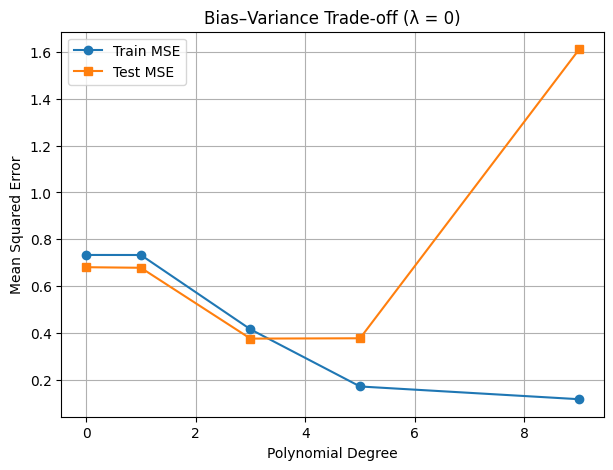

In [16]:
# ==============================
# 1. Compare different polynomial degrees
# ==============================
degrees = [0, 1, 3, 5, 9]   # try simple → complex
train_mse_list, test_mse_list = [], []

for d in degrees:
    w = fit_poly_regression(X1, y1, degree=d, lam=0.0)
    y_train_pred = predict_poly(X1, w)
    y_test_pred  = predict_poly(Xt, w)
    train_mse_list.append(mse(y1, y_train_pred))
    test_mse_list.append(mse(yt, y_test_pred))

# Plot MSE vs degree
plt.figure(figsize=(7, 5))
plt.plot(degrees, train_mse_list, 'o-', label='Train MSE')
plt.plot(degrees, test_mse_list, 's-', label='Test MSE')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Bias–Variance Trade-off (λ = 0)")
plt.legend()
plt.grid(True)
plt.show()

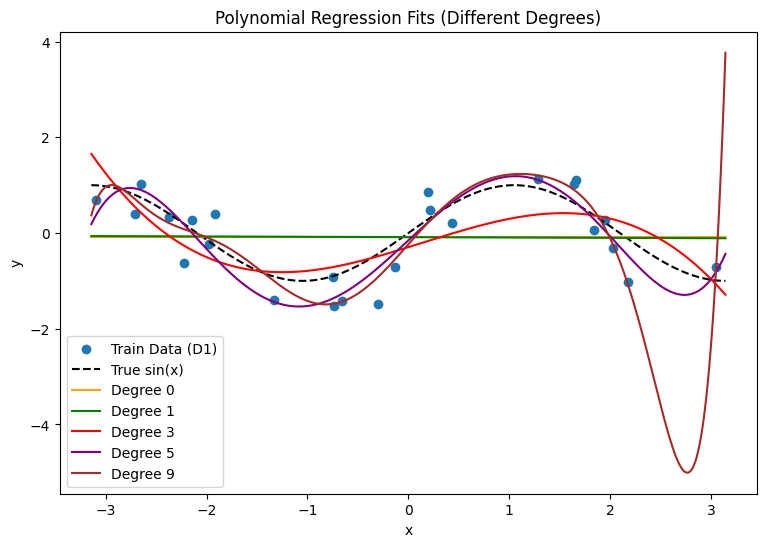

In [17]:
# ==============================
# 2. Visualize model fits
# ==============================
x_plot = np.linspace(start_point, end_point, 400).reshape(-1, 1)
y_true = np.sin(freq * x_plot)

plt.figure(figsize=(9, 6))
plt.scatter(X1, y1, color='tab:blue', label='Train Data (D1)')
plt.plot(x_plot, y_true, 'k--', label='True sin(x)')

colors = ['orange', 'green', 'red', 'purple', 'brown']
for d, c in zip(degrees, colors):
    w = fit_poly_regression(X1, y1, degree=d)
    plt.plot(x_plot, predict_poly(x_plot, w), color=c, label=f'Degree {d}')

plt.title("Polynomial Regression Fits (Different Degrees)")
plt.xlabel("x");  plt.ylabel("y")
plt.legend()
plt.show()


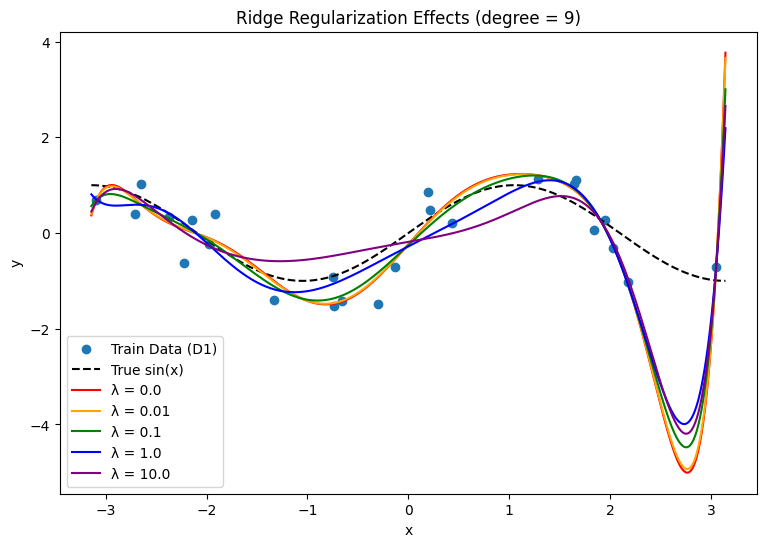

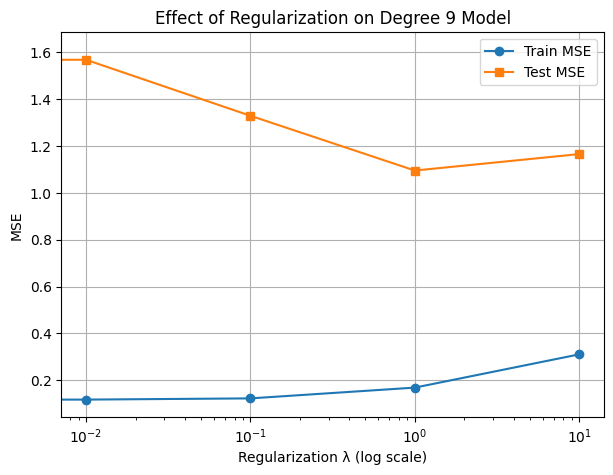

In [18]:
# ==============================
# 3. Effect of regularization (Ridge)
# ==============================
degree = 9
lambdas = [0.0, 0.01, 0.1, 1.0, 10.0]
plt.figure(figsize=(9, 6))
plt.scatter(X1, y1, color='tab:blue', label='Train Data (D1)')
plt.plot(x_plot, y_true, 'k--', label='True sin(x)')

for lam, color in zip(lambdas, ['red', 'orange', 'green', 'blue', 'purple']):
    w = fit_poly_regression(X1, y1, degree=degree, lam=lam)
    plt.plot(x_plot, predict_poly(x_plot, w), color=color, label=f'λ = {lam}')

plt.title(f'Ridge Regularization Effects (degree = {degree})')
plt.xlabel("x");  plt.ylabel("y")
plt.legend()
plt.show()

# Evaluate λ impact on errors
train_mse_ridge, test_mse_ridge = [], []
for lam in lambdas:
    w = fit_poly_regression(X1, y1, degree=degree, lam=lam)
    train_mse_ridge.append(mse(y1, predict_poly(X1, w)))
    test_mse_ridge.append(mse(yt, predict_poly(Xt, w)))

plt.figure(figsize=(7, 5))
plt.plot(lambdas, train_mse_ridge, 'o-', label='Train MSE')
plt.plot(lambdas, test_mse_ridge, 's-', label='Test MSE')
plt.xscale('log')
plt.xlabel("Regularization λ (log scale)")
plt.ylabel("MSE")
plt.title("Effect of Regularization on Degree 9 Model")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# ==============================
# Print results (4-decimal truncation)
# ==============================
print("=== MSE by Polynomial Degree (λ = 0) ===")
for d, tr, te in zip(degrees, train_mse_list, test_mse_list):
    print(f"Degree {d}: Train MSE = {truncate_4(tr):.4f}, Test MSE = {truncate_4(te):.4f}")

print("\n=== Ridge (λ) Effect for Degree 9 ===")
for lam, tr, te in zip(lambdas, train_mse_ridge, test_mse_ridge):
    print(f"λ = {lam:<6}: Train MSE = {truncate_4(tr):.4f}, Test MSE = {truncate_4(te):.4f}")

=== MSE by Polynomial Degree (λ = 0) ===
Degree 0: Train MSE = 0.7330, Test MSE = 0.6807
Degree 1: Train MSE = 0.7329, Test MSE = 0.6783
Degree 3: Train MSE = 0.4154, Test MSE = 0.3757
Degree 5: Train MSE = 0.1713, Test MSE = 0.3771
Degree 9: Train MSE = 0.1168, Test MSE = 1.6118

=== Ridge (λ) Effect for Degree 9 ===
λ = 0.0   : Train MSE = 0.1168, Test MSE = 1.6118
λ = 0.01  : Train MSE = 0.1169, Test MSE = 1.5685
λ = 0.1   : Train MSE = 0.1221, Test MSE = 1.3292
λ = 1.0   : Train MSE = 0.1682, Test MSE = 1.0954
λ = 10.0  : Train MSE = 0.3102, Test MSE = 1.1656
